In [17]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [18]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.h5'

# 分類数設定

In [19]:
# First, let's check the actual number of classes in the data
import os
import numpy as np

dataset = 'model/keypoint_classifier/keypoint.csv'

temp_y = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))
unique_classes = np.unique(temp_y)
max_class = np.max(temp_y)
min_class = np.min(temp_y)

print(f"Unique classes in data: {unique_classes}")
print(f"Max class label: {max_class}, Min class label: {min_class}")
print(f"Actual number of unique labels: {len(unique_classes)}")

# Use max label + 1 so sparse_categorical_crossentropy accepts labels up to the highest value.
NUM_CLASSES = int(max_class) + 1
print(f"NUM_CLASSES set to {NUM_CLASSES} (max label + 1)")

Unique classes in data: [0 1 2 3 4 5 6 7 8 9]
Max class label: 9, Min class label: 0
Actual number of unique labels: 10
NUM_CLASSES set to 10 (max label + 1)


# 学習データ読み込み

In [20]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [21]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# モデル構築

In [23]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [24]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_2 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180 (4.61 KB)

 Trainable params: 1,180 (4.61 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [26]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [27]:
model.fit(
    X_train,
    y_train,
    epochs=250,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback]
)

Epoch 1/250
44/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1145 - loss: 2.2978
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1460 - loss: 2.2516 - val_accuracy: 0.2604 - val_loss: 2.1281
Epoch 2/250
45/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2128 - loss: 2.1286 
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2247 - loss: 2.0885 - val_accuracy: 0.3496 - val_loss: 1.9013
Epoch 3/250
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2575 - loss: 1.9721
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2736 - loss: 1.9398 - val_accuracy: 0.3655 - val_loss: 1.7355
Epoch 4/250
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3086 - loss: 1.8427
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3206 - loss: 1.8307 - val_accuracy: 0.4210 - val_loss: 1.5884
Epoch 5/250
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3664 - loss: 1.7429
Epoch 5: saving model to model/keypoint_classifier/keypoint_classifier.h5


...

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7366 - loss: 0.7314 - val_accuracy: 0.9008 - val_loss: 0.3433
Epoch 247/250
40/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7420 - loss: 0.7361
Epoch 247: saving model to model/keypoint_classifier/keypoint_classifier.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7547 - loss: 0.7081 - val_accuracy: 0.9094 - val_loss: 0.3351
Epoch 248/250
47/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7368 - loss: 0.7689
Epoch 248: saving model to model/keypoint_classifier/keypoint_classifier.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7407 - loss: 0.7336 - val_accuracy: 0.8980 - val_loss: 0.3458
Epoch 249/250
48/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7597 - loss: 0.6989
Epoch 249: saving model to model/keypoint_classifier/keypoint_classifier.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7542 - loss: 0.7067 - val_accuracy: 0.8871 - val_loss: 0.3428
Epoch 250/250
47/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7487 - loss: 0.7117
Epoch 250: saving model to model/keypoint_classifier/keypoint_classifier.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7522 - loss: 0.7100 - val_accuracy: 0.8971 - val_loss: 0.3469


In [28]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8971 - loss: 0.3469 


In [29]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [30]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
[6.5165441e-05 9.8459691e-01 1.0316586e-03 1.0889470e-05 1.5417631e-07
 1.2476935e-02 1.3218493e-03 2.8728793e-04 5.0762042e-12 2.0926651e-04]
1


In [31]:
!pip install seaborn



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 混同行列

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


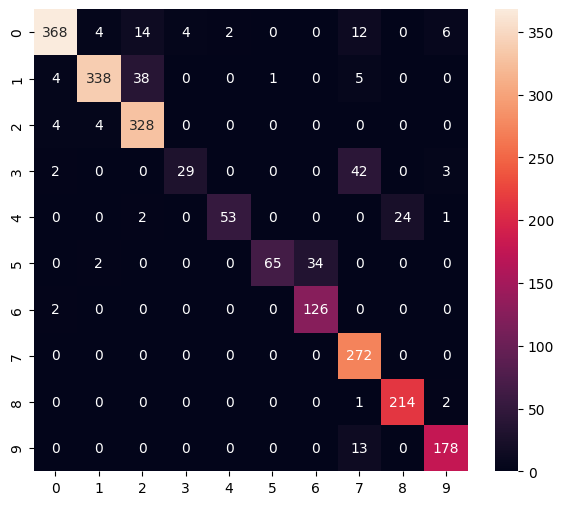

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       410
           1       0.97      0.88      0.92       386
           2       0.86      0.98      0.91       336
           3       0.88      0.38      0.53        76
           4       0.96      0.66      0.79        80
           5       0.98      0.64      0.78       101
           6       0.79      0.98      0.88       128
           7       0.79      1.00      0.88       272
           8       0.90      0.99      0.94       217
           9       0.94      0.93      0.93       191

    accuracy                           0.90      2197
   macro avg       0.90      0.83      0.85      2197
weighted avg       0.91      0.90      0.89      2197



In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [33]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

In [34]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\GURURA~1\AppData\Local\Temp\tmpn7sw_4lv\assets


INFO:tensorflow:Assets written to: C:\Users\GURURA~1\AppData\Local\Temp\tmpn7sw_4lv\assets


Saved artifact at 'C:\Users\GURURA~1\AppData\Local\Temp\tmpn7sw_4lv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1319174842048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1319184026432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1319203720000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1319203720704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1319203725632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1319203726336: TensorSpec(shape=(), dtype=tf.resource, name=None)


6820

# 推論テスト

In [35]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

c:\Users\Gururamdas\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [36]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [37]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [38]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 4 ms


In [39]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[6.5165492e-05 9.8459679e-01 1.0316580e-03 1.0889489e-05 1.5417658e-07
 1.2476952e-02 1.3218522e-03 2.8728790e-04 5.0762133e-12 2.0926748e-04]
1
